In [19]:
import numpy as np
import pandas as pd
import time

In [20]:
df=pd.read_csv('/content/Social_Network_Ads.csv')
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [27]:
x,y=df.iloc[:,0:-1],df.iloc[:,-1]
x.shape, y.shape

((400, 2), (400,))

In [28]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=2)
xtrain.shape, xtest.shape, ytrain.shape, ytest.shape

((320, 2), (80, 2), (320,), (80,))

In [29]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
xtrains=sc.fit_transform(xtrain)
xtests=sc.transform(xtest)

In [30]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [31]:
model=Sequential()
model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
s=time.time()
history=model.fit(xtrains,ytrain,epochs=10,batch_size=320) # BATCH_GD as batch_size=xtrain.shape[0]
print(time.time()-s)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step - accuracy: 0.7219 - loss: 0.6471
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7250 - loss: 0.6409
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7344 - loss: 0.6367
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7500 - loss: 0.6332
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7563 - loss: 0.6301
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7594 - loss: 0.6273
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7625 - loss: 0.6246
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7656 - loss: 0.6220
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7688 - loss: 0.6196
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7688 - loss: 0.6172
1.069368839263916


From the above execution we can observe Batch GD takes less time to execute, but its accuracy is 67.5% and not much reduction in Loss.

In [18]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
s=time.time()
history=model.fit(xtrains,ytrain,epochs=500,batch_size=1) # STOCHASTIC_GD as batch_size=1
print(time.time()-s)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6844 - loss: 0.5516
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8125 - loss: 0.3907
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8313 - loss: 0.3286
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8469 - loss: 0.2988
Epoch 5/500
250/320 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8868 - loss: 0.2740

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1496/2024134121.py", line 3, in <cell line: 0>
    history=model.fit(xtrains,ytrain,epochs=500,batch_size=1) # STOCHASTIC_GD as batch_size=1
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 400, in fit
    callbacks.on_train_batch_end(end_step, logs)
  File "/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py", line 198, in on_train_batch_end
    self._on_train_batch_end(batch, logs)
  File "/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py", l

TypeError: object of type 'NoneType' has no len()

1. STOCHASTIC GD takes more time duration to execute as it needed to perform 320 weights and bias updates every epoch for 10 epochs.
2. But we can observe the accuracy was high to start with as compared with BATCH GD and improved significantly to 90%.
3. Also Loss had seen a significant reduction from 0.6207 to 0.2581.

As per #2 and #3 we can understand the SGD converges significantly faster compared to Batch GD.

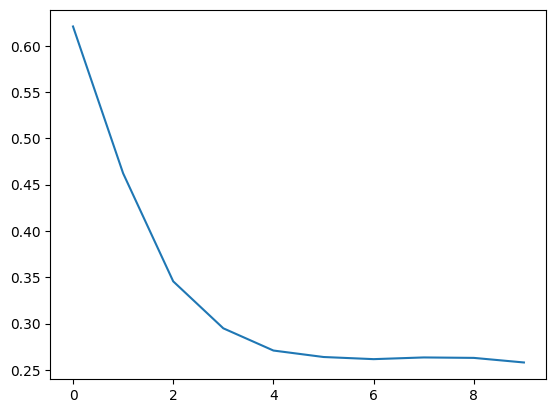

In [ ]:
from matplotlib import pyplot as plt
plt.plot(history.history['loss'])
plt.show();

In [32]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
s=time.time()
history=model.fit(xtrains,ytrain,epochs=500,batch_size=32) # MINIBATCH_GD as batch_size is neither 1 nor the record count of xtrain set.
print(time.time()-s)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5969 - loss: 0.6792
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7594 - loss: 0.6501
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7844 - loss: 0.6302
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7781 - loss: 0.6126  
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7906 - loss: 0.5957
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7906 - loss: 0.5795 
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8031 - loss: 0.5631
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8031 - loss: 0.5472
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8125 - loss: 0.5318
Epoch 10/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8156 - loss: 0.5164
Epoch 11/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8156 - loss: 0.5013
Epoch 12/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

MiniBatch GD sits comfortably between Batch GD and Stochastic GD to utilize vectorization and also converge quickly with less spikes in convergence pattern.